# Задача 1: Лингвистика и синтаксический разбор

Начальный пример для работы с задачей.

In [ ]:
# Установка необходимых библиотек
!pip install spacy
!pip install matplotlib
!pip install pandas
!python -m spacy download en_core_web_sm  # Английская модель

## Импорт необходимых библиотек

In [12]:
from collections import Counter
import json
import re
import matplotlib.pyplot as plt
import pandas as pd
import spacy
from spacy import displacy
import csv

## Загрузка данных

In [24]:
def load_texts(file_path):
    """
    Загружает текстовые данные из файла.
    
    Args:
        file_path: путь к файлу с текстами
    
    Returns:
        list: список предложений
    """
    # TODO: реализовать загрузку текстов
    # Подсказка: можно использовать json.load() если данные в JSON формате
    # или просто читать построчно если это текстовый файл
    # Пример для текстового файла:
    # with open(file_path, 'r', encoding='utf-8') as f:
    #     text = f.read()
    #     sentences = re.split(r'[.!?]+', text)
    #     return [s.strip() for s in sentences if s.strip()]
    sentences = []
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            # Пропускаем заголовок
            header = next(reader, None)
            
            for row in reader:
                if row:  #Проверка на пустую строку
                    # Колонка в которой текст
                    text = row[0].strip()
                    if text:
                        sentences.append(text)
                        
        return sentences
    
    except FileNotFoundError:
        print(f"Файл {file_path} не найден")
        return []
    except Exception as e:
        print(f"Ошибка при чтении файла: {e}")
        return []


In [25]:
# Пример использования
# texts = load_texts('data/texts.txt')
# print(f"Загружено предложений: {len(texts)}")
texts = load_texts('NewsDataset.csv')
print(f"Загружено предложений: {len(texts)}")
for i, text in enumerate(texts[:5]):  # Покажем первые 5
    print(f"{i+1}. {text}")

Загружено предложений: 100713
1. Celeb chef Anthony Bourdain wins multiple Emmys posthumously
2. Clearly something is wrong with US, says JPMorgan CEO
3. Two more allegedly commit suicide over Maratha quota demand
4. Must curb hate speeches during poll campaigns: Ex-EC chiefs
5. PNB to block all Maestro debit cards from July 31


## Инициализация инструментов

In [53]:
# Загрузка модели spaCy (для английского текста)
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Загрузка модели spaCy...")
    spacy.cli.download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

## Синтаксический разбор предложений

In [63]:
def parse_sentence(sentence, nlp):
    """
    Синтаксический разбор предложения с корректной обработкой be.
    """
    doc = nlp(sentence)
    
    subject = None
    predicate = None
    
    be_forms = ['be', 'am', 'is', 'are', 'was', 'were', 'being', 'been']
    
    # Сначала ищем корень-глагол
    for token in doc:
        if token.dep_ == "ROOT" and token.pos_ in ["VERB", "AUX"]:
            predicate = token.lemma_.lower()
            break
    
    # Если не нашли корень-глагол, ищем be-связку
    if not predicate:
        for token in doc:
            if token.dep_ == "cop" and token.lemma_.lower() in be_forms:
                predicate = token.lemma_.lower()
                break
    
    # Если все еще не нашли, ищем любой be
    if not predicate:
        for token in doc:
            if token.lemma_.lower() in be_forms:
                predicate = token.lemma_.lower()
                break
    
    # Поиск подлежащего (независимо от сказуемого)
    for token in doc:
        if token.dep_ in ["nsubj", "nsubjpass"] and not subject:
            subject = token.text.lower()
            break
    
    return subject, predicate

In [17]:
def is_predicate(word, nlp):
    """
    Проверяет, является ли слово сказуемым.
    
    Args:
        word: слово для проверки
        nlp: объект spaCy Language
    
    Returns:
        bool: True если слово является сказуемым
    """
    doc = nlp(word)
    if len(doc) > 0:
        token = doc[0]
        # Проверяем, что часть речи - глагол или вспомогательный глагол
        return token.pos_ in ["VERB", "AUX"]
    return False

In [51]:
def build_cooccurrence_dependencies(texts, nlp, sample_size=None):
    """
    Строит зависимости совместных употреблений подлежащих и сказуемых.
    
    Args:
        texts: список предложений
        nlp: объект spaCy Language
        sample_size: количество предложений для обработки (None - все)
    
    Returns:
        Counter: счетчик пар (подлежащее, сказуемое)
    """
    cooccurrences = []
    
    # Ограничиваем количество предложений для обработки, если указано
    if sample_size:
        texts_to_process = texts[:sample_size]
    else:
        texts_to_process = texts
    
    print(f"Обработка {len(texts_to_process)} предложений...")
    
    for i, sentence in enumerate(texts_to_process):
        if i % 1000 == 0 and i > 0:
            print(f"Обработано {i} предложений...")
        
        try:
            subject, predicate = parse_sentence(sentence, nlp)
            if subject and predicate:
                cooccurrences.append((subject, predicate))
        except Exception as e:
            # Пропускаем проблемные предложения
            continue
    
    print(f"Найдено {len(cooccurrences)} пар (подлежащее, сказуемое)")
    return Counter(cooccurrences)

## Визуализация результатов

In [57]:
def visualize_results(counter, top_n=20):
    """
    Визуализирует результаты анализа.
    
    Args:
        counter: Counter с парами (подлежащее, сказуемое)
        top_n: количество топовых сочетаний для отображения
    """
    #top_n наиболее частых сочетаний
    top_pairs = counter.most_common(top_n)
    
    if not top_pairs:
        print("Нет данных для визуализации")
        return
    
    #каждый элемент это ((subject, predicate), count)
    pairs = [f"{subj} → {pred}" for (subj, pred), count in top_pairs]
    counts = [count for (subj, pred), count in top_pairs]
    
    # Создаем figure с двумя подграфиками
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    
    # График 1: Столбчатая диаграмма
    y_pos = range(len(pairs))
    bars = ax1.barh(y_pos, counts, color='skyblue', edgecolor='navy')
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(pairs, fontsize=10)
    ax1.invert_yaxis()
    ax1.set_xlabel('Частота встречаемости', fontsize=12)
    ax1.set_title(f'Топ-{top_n} наиболее частых сочетаний "подлежащее → сказуемое"', fontsize=14, fontweight='bold')
    
    # Добавляем значения на столбцы
    for i, (bar, v) in enumerate(zip(bars, counts)):
        ax1.text(v + 0.5, bar.get_y() + bar.get_height()/2, 
                str(v), va='center', fontsize=9, fontweight='bold')
    
    # График 2: Круговая диаграмма для топ-10
    top_10_pairs = top_pairs[:10]
    
    labels = [f"{subj}→{pred}" for (subj, pred), count in top_10_pairs]
    sizes = [count for (subj, pred), count in top_10_pairs]
    
    # Цветовая схема для круговой диаграммы
    colors = plt.cm.Set3(range(len(sizes)))
    
    wedges, texts, autotexts = ax2.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                        startangle=90, colors=colors,
                                        textprops={'fontsize': 9})
    
    # Настройка внешнего вида текста на круговой диаграмме
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    ax2.set_title('Распределение топ-10 сочетаний', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Вывод таблицы с результатами
    print("\n" + "="*80)
    print(f"Топ-{top_n} наиболее частых сочетаний:")
    print("="*80)
    
    # Создаем DataFrame для таблицы
    data = []
    for i, ((subj, pred), count) in enumerate(top_pairs, 1):
        data.append({
            '№': i,
            'Подлежащее': subj,
            'Сказуемое': pred,
            'Частота': count,
            'Доля (%)': f"{count/sum(counts)*100:.1f}%"
        })
    
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    
    #статистика
    print("\n" + "="*80)
    print("Статистика:")
    print("="*80)
    print(f"Всего уникальных пар: {len(counter)}")
    print(f"Общее количество пар: {sum(counter.values())}")
    print(f"Средняя частота: {sum(counter.values())/len(counter):.2f}")
    print(f"Максимальная частота: {max(counter.values())}")
    print(f"Минимальная частота: {min(counter.values())}")

## Основной код выполнения задачи

Загрузка данных...
Загружено предложений: 100713

Обработка первых 100000 предложений...

Анализ синтаксической структуры предложений:

1. Текст: Celeb chef Anthony Bourdain wins multiple Emmys posthumously
   Подлежащее: Bourdain
   Сказуемое: wins (лемма: win)
   Основные синтаксические зависимости:
      Bourdain (PROPN) → nsubj → wins
      wins (VERB) → ROOT → wins
      Emmys (PROPN) → dobj → wins

2. Текст: Clearly something is wrong with US, says JPMorgan CEO
   Подлежащее: CEO
   Сказуемое: says (лемма: say)
   Основные синтаксические зависимости:
      something (PRON) → nsubj → is
      says (VERB) → ROOT → says
      CEO (PROPN) → nsubj → says

3. Текст: Two more allegedly commit suicide over Maratha quota demand
   Подлежащее: Two
   Сказуемое: commit (лемма: commit)
   Основные синтаксические зависимости:
      Two (NUM) → nsubj → commit
      commit (VERB) → ROOT → commit
      suicide (NOUN) → dobj → commit

4. Текст: Must curb hate speeches during poll campaigns: Ex-EC

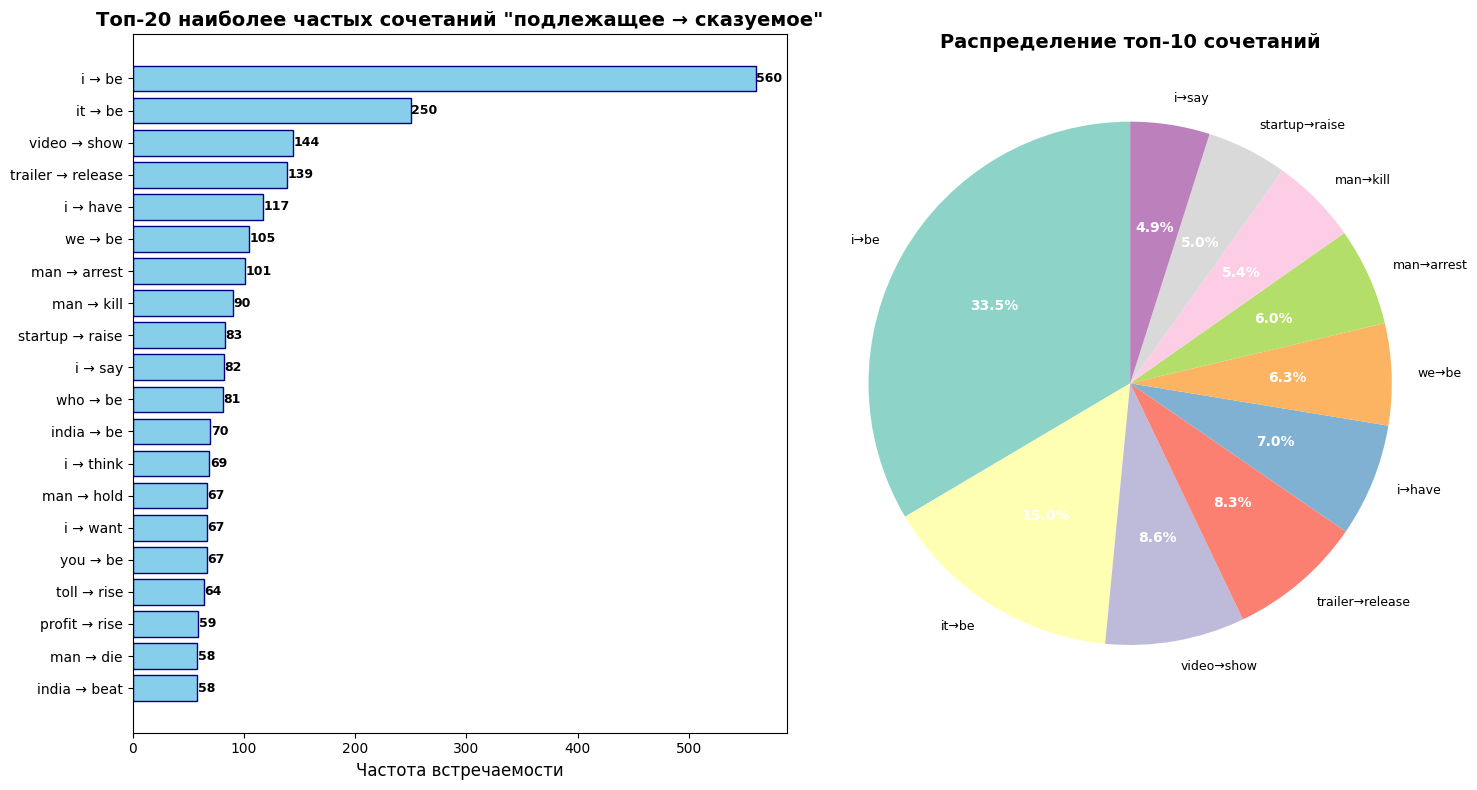


Топ-20 наиболее частых сочетаний:
 № Подлежащее Сказуемое  Частота Доля (%)
 1          i        be      560    24.0%
 2         it        be      250    10.7%
 3      video      show      144     6.2%
 4    trailer   release      139     6.0%
 5          i      have      117     5.0%
 6         we        be      105     4.5%
 7        man    arrest      101     4.3%
 8        man      kill       90     3.9%
 9    startup     raise       83     3.6%
10          i       say       82     3.5%
11        who        be       81     3.5%
12      india        be       70     3.0%
13          i     think       69     3.0%
14        man      hold       67     2.9%
15          i      want       67     2.9%
16        you        be       67     2.9%
17       toll      rise       64     2.7%
18     profit      rise       59     2.5%
19        man       die       58     2.5%
20      india      beat       58     2.5%

Статистика:
Всего уникальных пар: 49668
Общее количество пар: 74295
Средняя частот

In [68]:
# Основной код выполнения задачи

# данные
print("Загрузка данных...")
texts = load_texts('NewsDataset.csv')
print(f"Загружено предложений: {len(texts)}")


sample_size = 100000  # Количество предложений для обработки
print(f"\nОбработка первых {sample_size} предложений...")

# Анализ структуры предложений
analyze_sentence_structure(texts, nlp, num_examples=5)

# Построение зависимостей
print("\n" + "="*60)
print("Построение зависимостей подлежащее-сказуемое:")
print("="*60)

cooccurrences = build_cooccurrence_dependencies(
    texts, 
    nlp,
    sample_size=sample_size
)

# Вывод результатов
print("\n" + "="*60)
print("Топ-10 наиболее частых сочетаний:")
print("="*60)
for (subject, predicate), count in cooccurrences.most_common(10):
    print(f"'{subject}' → '{predicate}': {count} раз(а)")


visualize_results(cooccurrences, top_n=20)


